In [ ]:
import os, json
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
from tensorflow.keras import layers, models, callbacks
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.utils.class_weight import compute_class_weight
import seaborn as sns
import albumentations as A

gpus = tf.config.list_physical_devices('GPU')
if gpus:
    print(f'GPU ready: {gpus[0].name}')
else:
    print('No GPU found — training on CPU.')
print(f'TensorFlow: {tf.__version__}')

No GPU found — training on CPU.
TensorFlow: 2.21.0


In [ ]:
BASE_DIR   = r'D:/FYP/dental-vision/ML/data/processed'
TRAIN_DIR  = os.path.join(BASE_DIR, 'train')
VAL_DIR    = os.path.join(BASE_DIR, 'valid')
TEST_DIR   = os.path.join(BASE_DIR, 'test')
MODEL_DIR  = r'D:/FYP/dental-vision/ML/Models'
os.makedirs(MODEL_DIR, exist_ok=True)
IMG_SIZE    = 224
BATCH_SIZE  = 32
EPOCHS      = 40
NUM_CLASSES = 5
LR          = 1e-3
MODEL_SAVE  = os.path.join(MODEL_DIR, 'dental_model_v3_focal.keras')
print('Config ready.')

Config ready.


In [ ]:
xray_augment = A.Compose([
    A.CLAHE(clip_limit=2.0, tile_grid_size=(8, 8), p=0.5),
    A.RandomBrightnessContrast(brightness_limit=0.15, contrast_limit=0.15, p=0.5),
    A.GaussNoise(var_limit=(5, 20), p=0.3),
    A.ElasticTransform(alpha=30, sigma=5, p=0.3),
    A.HorizontalFlip(p=0.5),
    A.ShiftScaleRotate(shift_limit=0.05, scale_limit=0.1, rotate_limit=10, p=0.5),
])
def albumentations_augment(image):
    image = image.astype(np.uint8)
    return xray_augment(image=image)['image'].astype(np.float32)
print('Augmentation pipeline ready.')

Augmentation pipeline ready.


C:\Users\HP\AppData\Local\Temp\ipykernel_34188\662583002.py:5: UserWarning: Argument(s) 'var_limit' are not valid for transform GaussNoise
  A.GaussNoise(var_limit=(5, 20), p=0.3),
d:\FYP\dental-vision\venv\Lib\site-packages\albumentations\core\validation.py:114: UserWarning: ShiftScaleRotate is a special case of Affine transform. Please use Affine transform instead.
  original_init(self, **validated_kwargs)


In [ ]:
train_datagen = ImageDataGenerator(rescale=1.0/255.0, preprocessing_function=albumentations_augment)
val_datagen   = ImageDataGenerator(rescale=1.0/255.0)
test_datagen  = ImageDataGenerator(rescale=1.0/255.0)
train_generator = train_datagen.flow_from_directory(TRAIN_DIR, target_size=(IMG_SIZE,IMG_SIZE), batch_size=BATCH_SIZE, class_mode='categorical', shuffle=True, seed=42)
val_generator   = val_datagen.flow_from_directory(VAL_DIR, target_size=(IMG_SIZE,IMG_SIZE), batch_size=BATCH_SIZE, class_mode='categorical', shuffle=False)
test_generator  = test_datagen.flow_from_directory(TEST_DIR, target_size=(IMG_SIZE,IMG_SIZE), batch_size=BATCH_SIZE, class_mode='categorical', shuffle=False)
class_names = list(train_generator.class_indices.keys())
with open(os.path.join(MODEL_DIR, 'class_names.json'), 'w') as f:
    json.dump(class_names, f)
print(f'Classes: {class_names}')
print(f'Train steps: {len(train_generator)} | Val steps: {len(val_generator)}')

Found 13935 images belonging to 5 classes.
Found 3970 images belonging to 5 classes.
Found 2094 images belonging to 5 classes.
Classes: ['Bone_Loss', 'Caries', 'Impacted_Tooth', 'Missing_Teeth', 'Periapical_Lesion']
Train steps: 436 | Val steps: 125


In [ ]:
print('Class distribution:\n')
counts = np.bincount(train_generator.classes)
total  = len(train_generator.classes)
for i, (name, count) in enumerate(zip(class_names, counts)):
    print(f'  [{i}] {name:<30s} {count:5d} ({100*count/total:.1f}%)')
weights = compute_class_weight(class_weight='balanced', classes=np.unique(train_generator.classes), y=train_generator.classes)
class_weight_dict = dict(enumerate(weights))
print('\nClass weights:')
for idx, w in class_weight_dict.items():
    print(f'  [{idx}] {class_names[idx]:<30s} {w:.3f}')

Class distribution:

  [0] Bone_Loss                       1177 (8.4%)
  [1] Caries                          2182 (15.7%)
  [2] Impacted_Tooth                  7655 (54.9%)
  [3] Missing_Teeth                   1230 (8.8%)
  [4] Periapical_Lesion               1691 (12.1%)

Class weights:
  [0] Bone_Loss                      2.368
  [1] Caries                         1.277
  [2] Impacted_Tooth                 0.364
  [3] Missing_Teeth                  2.266
  [4] Periapical_Lesion              1.648


In [ ]:
alpha_array = np.array([class_weight_dict[i] for i in range(NUM_CLASSES)], dtype='float32')
alpha_array = alpha_array / alpha_array.sum() * NUM_CLASSES
def categorical_focal_loss(alpha, gamma=2.0):
    alpha_t = tf.constant(alpha, dtype=tf.float32)
    def loss_fn(y_true, y_pred):
        y_pred = tf.clip_by_value(y_pred, 1e-7, 1.0 - 1e-7)
        cross_entropy = -y_true * tf.math.log(y_pred)
        weight = alpha_t * tf.pow(1 - y_pred, gamma)
        return tf.reduce_sum(weight * cross_entropy, axis=-1)
    return loss_fn
print(f'Focal loss ready. Alpha: {np.round(alpha_array,3)}')

Focal loss ready. Alpha: [1.494 0.806 0.23  1.43  1.04 ]


In [ ]:
def residual_block(x, filters, stride=1):
    shortcut = x
    x = layers.Conv2D(filters, 3, strides=stride, padding='same', use_bias=False)(x)
    x = layers.BatchNormalization()(x)
    x = layers.ReLU()(x)
    x = layers.Conv2D(filters, 3, padding='same', use_bias=False)(x)
    x = layers.BatchNormalization()(x)
    if stride != 1 or shortcut.shape[-1] != filters:
        shortcut = layers.Conv2D(filters, 1, strides=stride, use_bias=False)(shortcut)
        shortcut = layers.BatchNormalization()(shortcut)
    x = layers.Add()([x, shortcut])
    x = layers.ReLU()(x)
    return x
def build_dental_cnn(input_shape, num_classes):
    inputs = layers.Input(shape=input_shape)
    x = layers.Conv2D(32, 7, strides=2, padding='same', use_bias=False)(inputs)
    x = layers.BatchNormalization()(x)
    x = layers.ReLU()(x)
    x = layers.MaxPooling2D(3, strides=2, padding='same')(x)
    x = residual_block(x, 64);  x = residual_block(x, 64)
    x = residual_block(x, 128, stride=2); x = residual_block(x, 128)
    x = residual_block(x, 256, stride=2); x = residual_block(x, 256); x = residual_block(x, 256)
    x = residual_block(x, 512, stride=2); x = residual_block(x, 512)
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dropout(0.4)(x)
    x = layers.Dense(256, activation='relu')(x)
    x = layers.Dropout(0.3)(x)
    outputs = layers.Dense(num_classes, activation='softmax')(x)
    return models.Model(inputs, outputs, name='DentalCNN_ResNet')
model = build_dental_cnn(input_shape=(IMG_SIZE, IMG_SIZE, 3), num_classes=NUM_CLASSES)
model.compile(optimizer=Adam(learning_rate=LR, clipnorm=1.0), loss=categorical_focal_loss(alpha_array, gamma=2.0), metrics=['accuracy'])
print(f'Model built: {model.count_params():,} params | focal loss | clipnorm=1.0')

Model built: 12,479,461 params | focal loss | clipnorm=1.0


In [ ]:
def cosine_lr_schedule(epoch, total_epochs=EPOCHS, lr_max=LR, lr_min=1e-6):
    return lr_min + 0.5*(lr_max-lr_min)*(1+np.cos(np.pi*epoch/total_epochs))
training_callbacks = [
    callbacks.ModelCheckpoint(filepath=MODEL_SAVE, monitor='val_accuracy', save_best_only=True, verbose=1),
    callbacks.EarlyStopping(monitor='val_accuracy', patience=8, restore_best_weights=True, verbose=1),
    callbacks.LearningRateScheduler(lambda epoch: cosine_lr_schedule(epoch), verbose=0),
    callbacks.CSVLogger(MODEL_SAVE.replace('.keras','_log.csv'), append=False),
]
print('Callbacks ready.')

Callbacks ready.


In [ ]:
print('Starting training...')
history = model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=EPOCHS,
    callbacks=training_callbacks,
    verbose=1
)
best_val_acc = max(history.history['val_accuracy'])
print(f'Done. Best val_accuracy: {best_val_acc*100:.2f}%')

Starting training...
Epoch 1/40
436/436 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - accuracy: 0.2755 - loss: 0.8463
Epoch 1: val_accuracy improved from None to 0.10856, saving model to D:/FYP/dental-vision/ML/Models\dental_model_v3_focal.keras

Epoch 1: finished saving model to D:/FYP/dental-vision/ML/Models\dental_model_v3_focal.keras
436/436 ━━━━━━━━━━━━━━━━━━━━ 1518s 3s/step - accuracy: 0.3099 - loss: 0.6930 - val_accuracy: 0.1086 - val_loss: 0.7494 - learning_rate: 0.0010
Epoch 2/40
436/436 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - accuracy: 0.3822 - loss: 0.5830
Epoch 2: val_accuracy improved from 0.10856 to 0.45869, saving model to D:/FYP/dental-vision/ML/Models\dental_model_v3_focal.keras

Epoch 2: finished saving model to D:/FYP/dental-vision/ML/Models\dental_model_v3_focal.keras
436/436 ━━━━━━━━━━━━━━━━━━━━ 1619s 4s/step - accuracy: 0.3892 - loss: 0.5773 - val_accuracy: 0.4587 - val_loss: 0.5526 - learning_rate: 9.9846e-04
Epoch 3/40
436/436 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - accuracy: 0.3915 - 

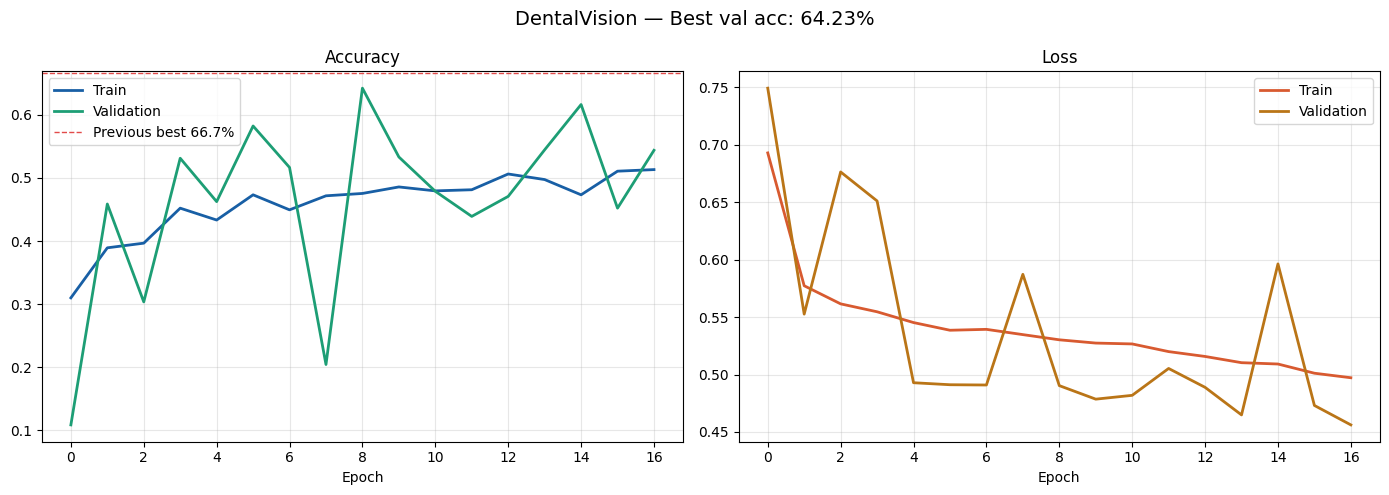

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].plot(history.history['accuracy'], label='Train', color='#185FA5', linewidth=2)
axes[0].plot(history.history['val_accuracy'], label='Validation', color='#1D9E75', linewidth=2)
axes[0].axhline(y=0.667, color='#E24B4A', linestyle='--', linewidth=1, label='Previous best 66.7%')
axes[0].set_title('Accuracy'); axes[0].set_xlabel('Epoch'); axes[0].legend(); axes[0].grid(True, alpha=0.3)
axes[1].plot(history.history['loss'], label='Train', color='#D85A30', linewidth=2)
axes[1].plot(history.history['val_loss'], label='Validation', color='#BA7517', linewidth=2)
axes[1].set_title('Loss'); axes[1].set_xlabel('Epoch'); axes[1].legend(); axes[1].grid(True, alpha=0.3)
plt.suptitle(f'DentalVision — Best val acc: {best_val_acc*100:.2f}%', fontsize=14)
plt.tight_layout()
plt.savefig(MODEL_SAVE.replace('.keras','_curves.png'), dpi=150, bbox_inches='tight')
plt.show()

In [ ]:
test_generator.reset()
y_pred_probs = model.predict(test_generator, verbose=1)
y_pred = np.argmax(y_pred_probs, axis=1)
y_true = test_generator.classes[:len(y_pred)]
test_accuracy = np.mean(y_pred == y_true)
print(f'Test Accuracy: {test_accuracy*100:.2f}%')

66/66 ━━━━━━━━━━━━━━━━━━━━ 38s 563ms/step
Test Accuracy: 67.91%


In [ ]:
print('Classification Report:\n')
print(classification_report(y_true, y_pred, target_names=class_names))

Classification Report:

                   precision    recall  f1-score   support

        Bone_Loss       0.06      0.03      0.04       100
           Caries       0.42      0.37      0.40       269
   Impacted_Tooth       0.81      0.93      0.87      1340
    Missing_Teeth       0.26      0.39      0.31       173
Periapical_Lesion       0.11      0.00      0.01       212

         accuracy                           0.68      2094
        macro avg       0.33      0.35      0.32      2094
     weighted avg       0.61      0.68      0.64      2094



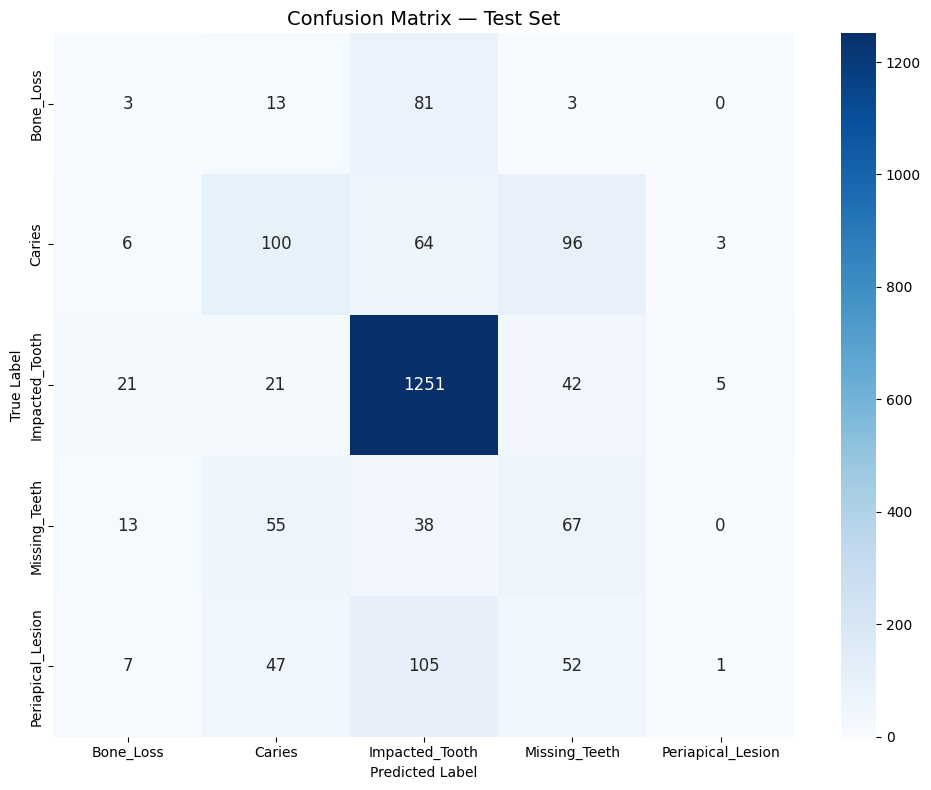

Confusion matrix saved.


In [ ]:
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names, annot_kws={'size':12})
plt.title('Confusion Matrix — Test Set', fontsize=14)
plt.ylabel('True Label'); plt.xlabel('Predicted Label')
plt.tight_layout()
plt.savefig(os.path.join(MODEL_DIR,'confusion_matrix.png'), dpi=150, bbox_inches='tight')
plt.show()
print('Confusion matrix saved.')

In [ ]:
print('='*60)
print('DENTAL VISION — FINAL SUMMARY')
print('='*60)
print(f'Model         : {model.name}')
print(f'Parameters    : {model.count_params():,}')
print(f'Best Val Acc  : {best_val_acc*100:.2f}%')
print(f'Test Accuracy : {test_accuracy*100:.2f}%')
print(f'Model saved   : {MODEL_SAVE}')
print('='*60)

DENTAL VISION — FINAL SUMMARY
Model         : DentalCNN_ResNet
Parameters    : 12,479,461
Best Val Acc  : 64.23%
Test Accuracy : 67.91%
Model saved   : D:/FYP/dental-vision/ML/Models\dental_model_v3_focal.keras
